# GliZNet Forward Pass — Cosine Similarity at Each Stage

Step-by-step visualization of how label and text representations **co-evolve** through the aggregator.

At each stage, we compare labels to their **contemporaneous text representation** — not a static CLS:

| Stage | Labels | Text repr |
|-------|--------|-----------|
| 1. Raw | `[LAB]` token embeddings | CLS token (position 0) |
| 2. Round 1 | Aggregated `[LAB]` embeddings | `_text_repr_dense(labels, hidden_states)` — first cross-attention pooling |
| 3. Round 2 (enriched) | After `LabelContextAttention` | `_text_repr_dense(enriched_labels, hidden_states)` — re-pooled with enriched queries |

**Key insight**: The bilinear head scores `(round2_text, enriched_label)` pairs. The text side sharpens as labels refine.


In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

from gliznet import GliZNetForSequenceClassification, GliZNETTokenizer

# Select GPU with most free memory
if torch.cuda.is_available():
    free_mem = [torch.cuda.mem_get_info(i)[0] for i in range(torch.cuda.device_count())]
    DEVICE = f"cuda:{free_mem.index(max(free_mem))}"
else:
    DEVICE = "cpu"

MODEL_PATH = "../results/deberta-v3-base_20260519_152126/checkpoint-4000"

model = GliZNetForSequenceClassification.from_pretrained(
    MODEL_PATH,
).to(DEVICE, dtype=torch.float16).eval()
tokenizer = GliZNETTokenizer.from_pretrained(MODEL_PATH)

print(f"Device: {DEVICE}")
print(f"Model loaded from: {MODEL_PATH}")
print(f"Hidden size: {model.aggregator.hidden_size}")
print(f"Scoring: {model.aggregator.scoring.__class__.__name__}")
print(f"Label enrichment: {model.aggregator.label_context is not None}")

Loading weights:   0%|          | 0/209 [00:00<?, ?it/s]

Device: cuda:0
Model loaded from: ../results/deberta-v3-base_20260519_152126/checkpoint-4000
Hidden size: 768
Scoring: BilinearScoring
Label enrichment: True


In [2]:
# Define a sample text with labels (mix of true and false)
text = "New research shows that moderate coffee consumption may reduce the risk of Alzheimer's disease by up to 30%."
labels = ["medical_research", "nutrition_advice", "drug_development", "disease_prevention", "public_health_policy"]
expected = [True, False, False, True, False]

text = "After years of training and countless sacrifices, the athlete finally stood on the Olympic podium, tears streaming down her face as the national anthem played."
labels = ["athletic_achievement", "personal_sacrifice", "patriotism", "emotional_moment", "celebrity_gossip", "sports_injury", "political_protest", "entertainment_review", "historical_analysis", "travel_experience"]
expected = [True, True, True, True, False, False, False, False, False, False]

# Tokenize
batch = tokenizer([(text, labels)], return_tensors="pt")
batch = {k: v.to(DEVICE) for k, v in batch.items()}

print(f"Input shape: {batch['input_ids'].shape}")
print(f"Labels: {labels}")
print(f"\nExpected true:  {[l for l, e in zip(labels, expected) if e]}")
print(f"Expected false: {[l for l, e in zip(labels, expected) if not e]}")

Input shape: torch.Size([1, 70])
Labels: ['athletic_achievement', 'personal_sacrifice', 'patriotism', 'emotional_moment', 'celebrity_gossip', 'sports_injury', 'political_protest', 'entertainment_review', 'historical_analysis', 'travel_experience']

Expected true:  ['athletic_achievement', 'personal_sacrifice', 'patriotism', 'emotional_moment']
Expected false: ['celebrity_gossip', 'sports_injury', 'political_protest', 'entertainment_review', 'historical_analysis', 'travel_experience']


## Capture All Stages

Run the aggregator step by step, capturing both label AND text representations at each stage.


In [3]:
@torch.no_grad()
def get_all_stages(model, batch, labels):
    """Run the forward pass step by step, capturing label AND text representations at each stage."""
    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    lmask = batch["lmask"]
    
    # Stage 1: Raw encoder output
    encoder_output = model.backbone(input_ids=input_ids, attention_mask=attention_mask)
    hidden_states = encoder_output.last_hidden_state  # (1, L, D)
    
    agg = model.aggregator
    B, L, D = hidden_states.shape
    
    # Normalize (as the aggregator does)
    hidden_states_norm = F.normalize(hidden_states, p=2, dim=-1)
    
    # Identify positions
    lab_token_mask = input_ids == agg.lab_token_id
    text_mask = (lmask == 0) & (attention_mask == 1) & (~lab_token_mask)
    
    # CLS token (position 0) — the "text repr" at raw stage
    cls_emb = hidden_states_norm[0, 0]  # (D,)
    
    # Text token embeddings (for token-level heatmaps)
    text_positions = text_mask[0].nonzero(as_tuple=True)[0]
    text_token_embs = hidden_states_norm[0, text_positions]  # (T, D)
    
    # Raw label token embeddings
    lab_positions = lab_token_mask[0].nonzero(as_tuple=True)[0]
    raw_label_embs = hidden_states_norm[0, lab_positions]  # (K, D)
    
    # Stage 2: Aggregated labels
    aggregated_labels, all_batch_ids, all_label_ids, max_k = agg.aggregate_labels(
        input_ids, hidden_states_norm
    )
    agg_label_embs = aggregated_labels  # (N, D)
    
    # Build dense for context attention
    dense_labels = aggregated_labels.new_zeros(B, max_k, D)
    dense_labels[all_batch_ids, all_label_ids - 1] = aggregated_labels
    
    # Round 1 text pooling: _text_repr_dense with original labels as queries
    text_r1_dense = agg._text_repr_dense(dense_labels, hidden_states_norm, text_mask)  # (B, K, D)
    text_r1 = text_r1_dense[all_batch_ids, all_label_ids - 1]  # (N, D)
    
    # Stage 3: Enrichment + Round 2 text pooling
    if agg.label_context is not None:
        label_mask = torch.zeros(B, max_k, dtype=torch.bool, device=hidden_states.device)
        label_mask[all_batch_ids, all_label_ids - 1] = True
        dense_labels_enriched = agg.label_context(dense_labels, text_r1_dense, label_mask)
        enriched_label_embs = dense_labels_enriched[all_batch_ids, all_label_ids - 1]
        # Round 2: re-pool text with enriched labels
        text_r2_dense = agg._text_repr_dense(dense_labels_enriched, hidden_states_norm, text_mask)
        text_r2 = text_r2_dense[all_batch_ids, all_label_ids - 1]  # (N, D)
        # Final scoring inputs
        text_for_scoring = text_r2
        labels_for_scoring = enriched_label_embs
    else:
        enriched_label_embs = agg_label_embs
        text_r2 = cls_emb.unsqueeze(0).expand(len(labels), -1)
        text_for_scoring = hidden_states_norm[:, 0][all_batch_ids]
        labels_for_scoring = aggregated_labels
    
    # Stage 4: Bilinear scores
    logits = agg.scoring(text_for_scoring, labels_for_scoring)
    scores = torch.sigmoid(logits).squeeze(-1)
    
    return {
        # Raw stage
        "raw_label_embs": raw_label_embs,        # (K, D) - labels at raw stage
        "cls_emb": cls_emb,                      # (D,)   - text repr at raw stage
        # Round 1: aggregated labels + first text pooling
        "agg_label_embs": agg_label_embs,        # (N, D) - labels after gathering
        "text_r1": text_r1,                      # (N, D) - text repr at round 1
        # Round 2: enriched labels + re-pooled text
        "enriched_label_embs": enriched_label_embs,  # (N, D)
        "text_r2": text_r2,                      # (N, D) - text repr at round 2 (final)
        # Token-level (for detailed heatmaps)
        "text_token_embs": text_token_embs,      # (T, D)
        "text_positions": text_positions,
        # Final scores
        "logits": logits.squeeze(-1),
        "scores": scores,
        "labels": labels,
    }

stages = get_all_stages(model, batch, labels)
print("All stages captured.")
print(f"  Raw labels:     {stages['raw_label_embs'].shape}")
print(f"  Agg labels:     {stages['agg_label_embs'].shape}")
print(f"  Enriched labels:{stages['enriched_label_embs'].shape}")
print(f"  Text R1:        {stages['text_r1'].shape}")
print(f"  Text R2:        {stages['text_r2'].shape}")
print(f"  Text tokens:    {stages['text_token_embs'].shape}")

All stages captured.
  Raw labels:     torch.Size([10, 768])
  Agg labels:     torch.Size([10, 768])
  Enriched labels:torch.Size([10, 768])
  Text R1:        torch.Size([10, 768])
  Text R2:        torch.Size([10, 768])
  Text tokens:    torch.Size([30, 768])


In [4]:
def cos_sim(a, b):
    """Cosine similarity between vectors/matrices."""
    a = F.normalize(a, p=2, dim=-1)
    b = F.normalize(b, p=2, dim=-1)
    return (a @ b.T).cpu().numpy()


def plot_stage_heatmap(sim_matrix, row_labels, col_label, title, ax, vmin=-1, vmax=1):
    """Plot a cosine similarity heatmap."""
    sns.heatmap(
        sim_matrix, ax=ax, vmin=vmin, vmax=vmax, cmap="RdBu_r",
        xticklabels=[col_label] if isinstance(col_label, str) else col_label,
        yticklabels=row_labels,
        annot=True, fmt=".3f", annot_kws={"size": 9},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")

print("Helpers ready.")

Helpers ready.


## Label ↔ Text Cosine at Each Stage (Matched Pairs)

At each stage, compare each label to its **contemporaneous** text representation:
- **Raw**: `cos(label_i, CLS)` — all labels see the same global text summary
- **Round 1**: `cos(agg_label_i, text_r1_i)` — label-specific cross-attention pooling
- **Round 2**: `cos(enriched_label_i, text_r2_i)` — re-pooled after cooperative enrichment


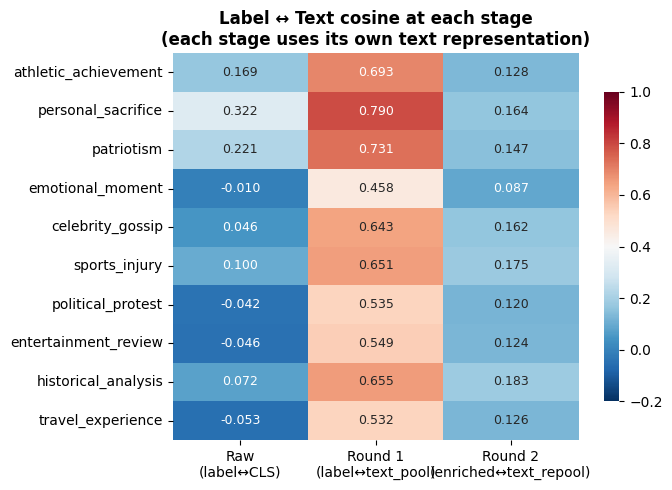


Label                       Raw↔CLS   R1↔text   R2↔text   Exp
────────────────────────────────────────────────────────────
athletic_achievement          0.169     0.693     0.128     T
personal_sacrifice            0.322     0.790     0.164     T
patriotism                    0.221     0.731     0.147     T
emotional_moment             -0.010     0.458     0.087     T
celebrity_gossip              0.046     0.643     0.162     F
sports_injury                 0.100     0.651     0.175     F
political_protest            -0.042     0.535     0.120     F
entertainment_review         -0.046     0.549     0.124     F
historical_analysis           0.072     0.655     0.183     F
travel_experience            -0.053     0.532     0.126     F


In [5]:
cls = stages["cls_emb"].unsqueeze(0)  # (1, D)

# Stage-matched cosine similarities
# Raw: each label vs CLS (broadcast)
sim_raw = cos_sim(stages["raw_label_embs"], cls).flatten()  # (K,)
# Round 1: each label vs its own text pooling
sim_r1 = np.array([
    cos_sim(stages["agg_label_embs"][i:i+1], stages["text_r1"][i:i+1]).item()
    for i in range(len(labels))
])
# Round 2: each enriched label vs its re-pooled text
sim_r2 = np.array([
    cos_sim(stages["enriched_label_embs"][i:i+1], stages["text_r2"][i:i+1]).item()
    for i in range(len(labels))
])

# Heatmap: (K, 3) matrix
sim_matrix = np.column_stack([sim_raw, sim_r1, sim_r2])
stage_cols = ["Raw\n(label↔CLS)", "Round 1\n(label↔text_pool)", "Round 2\n(enriched↔text_repool)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sim_matrix, ax=ax, vmin=-0.2, vmax=1.0, cmap="RdBu_r",
    xticklabels=stage_cols, yticklabels=labels,
    annot=True, fmt=".3f", annot_kws={"size": 9},
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Label ↔ Text cosine at each stage\n(each stage uses its own text representation)", 
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Table
print(f"\n{'Label':<25} {'Raw↔CLS':>9} {'R1↔text':>9} {'R2↔text':>9} {'Exp':>5}")
print("─" * 60)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {sim_raw[i]:>9.3f} {sim_r1[i]:>9.3f} {sim_r2[i]:>9.3f} {'T' if exp else 'F':>5}")

## Labels vs Text Tokens at Each Stage

How each label's attention over individual text tokens changes as labels evolve.


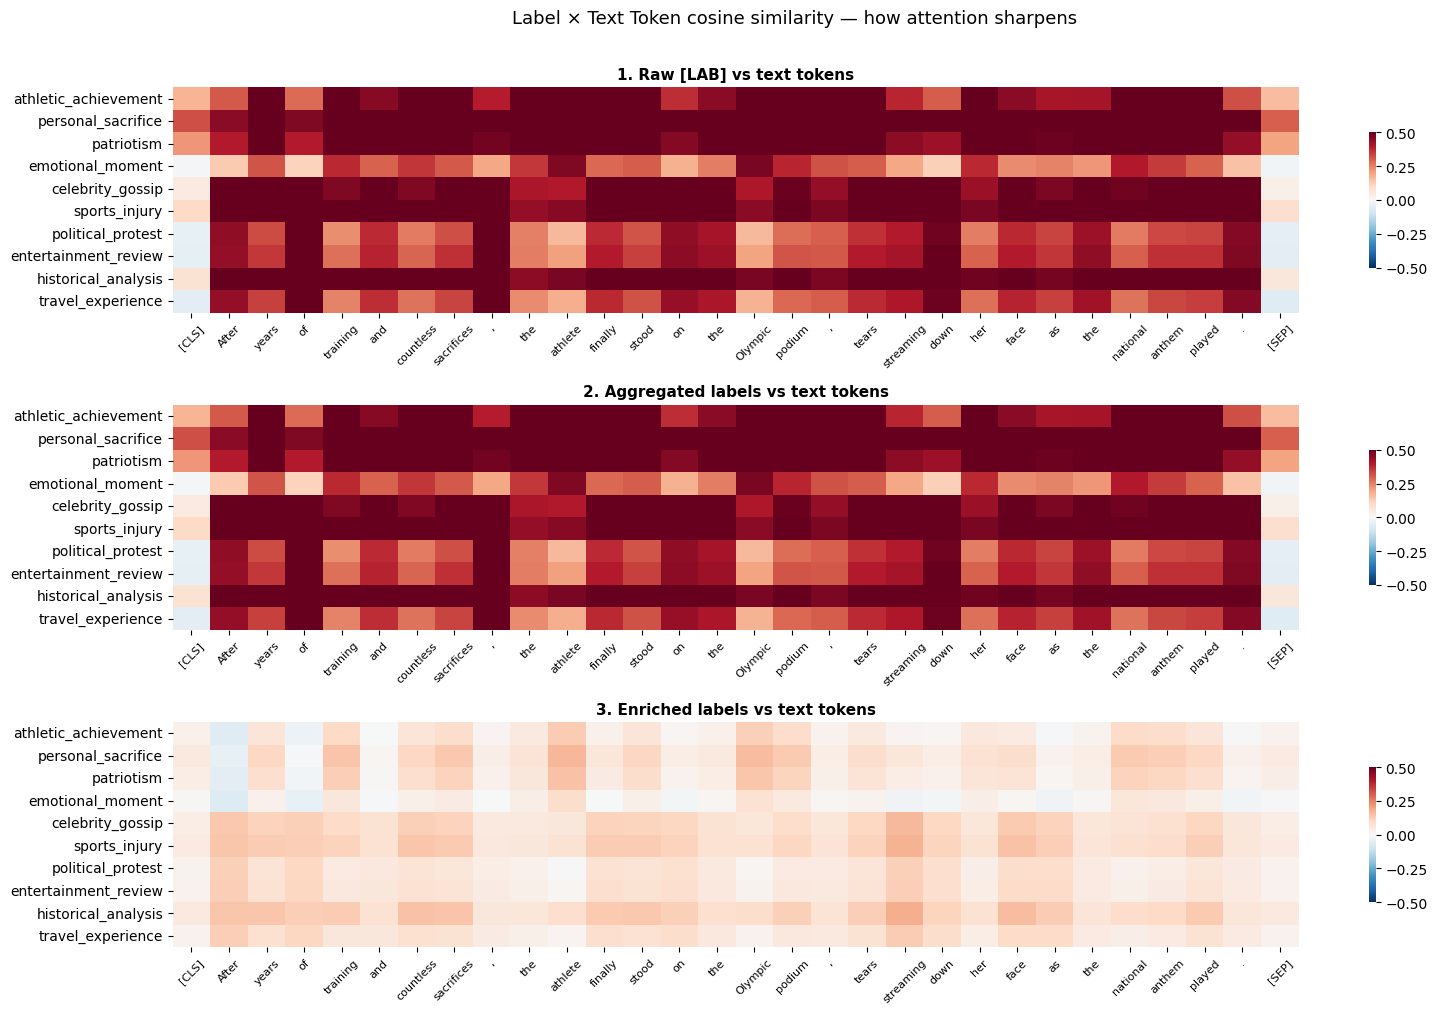

In [6]:
# Get text token strings for x-axis labels
token_ids = batch["input_ids"][0, stages["text_positions"]].cpu().tolist()
token_strs = tokenizer.tokenizer.convert_ids_to_tokens(token_ids)
token_strs = [t.replace("▁", "")[:12] for t in token_strs]

text_token_embs = stages["text_token_embs"]  # (T, D)

# Similarity matrices: labels × text tokens at each stage
sim_raw_text = cos_sim(stages["raw_label_embs"], text_token_embs)
sim_agg_text = cos_sim(stages["agg_label_embs"], text_token_embs)
sim_enr_text = cos_sim(stages["enriched_label_embs"], text_token_embs)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

for ax, sim, title in zip(axes, 
    [sim_raw_text, sim_agg_text, sim_enr_text],
    ["1. Raw [LAB] vs text tokens",
     "2. Aggregated labels vs text tokens",
     "3. Enriched labels vs text tokens"]):
    sns.heatmap(
        sim, ax=ax, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
        xticklabels=token_strs, yticklabels=labels,
        cbar_kws={"shrink": 0.6},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle("Label × Text Token cosine similarity — how attention sharpens", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Pairwise Similarities

1. **Label ↔ Label** — How labels relate to each other at each stage
2. **Text ↔ Text** — How text representations differ per label (same input, different attention)
3. **Cross: Label ↔ Text** — Full cross-matrix at the final stage (diagonal = scoring input)


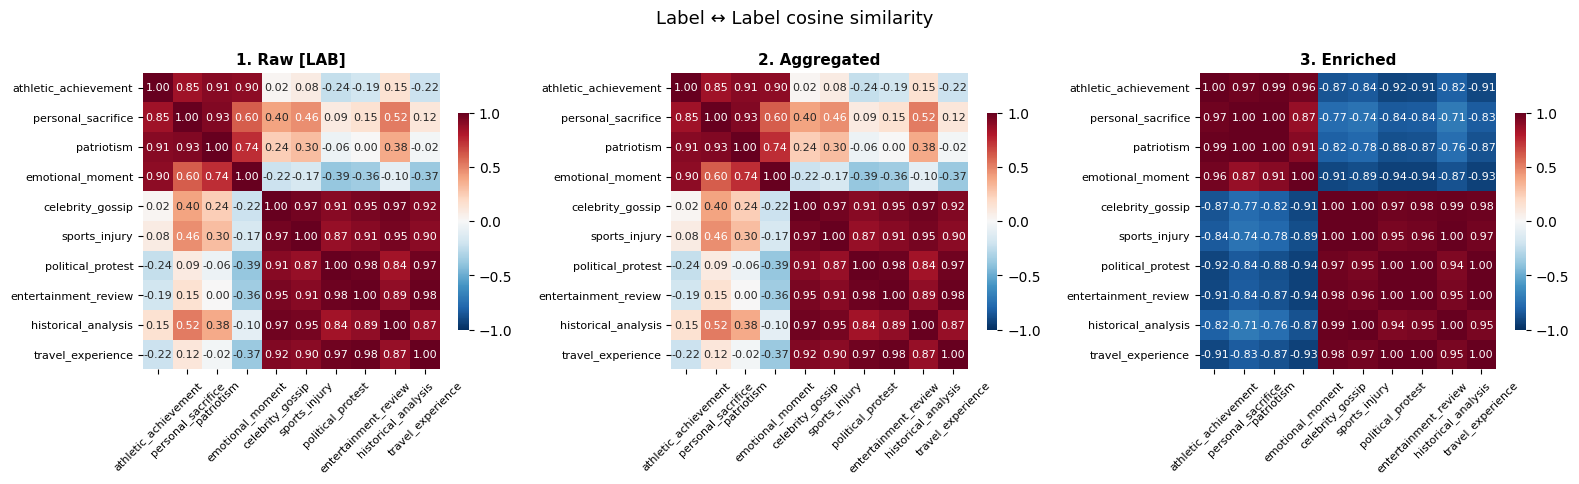

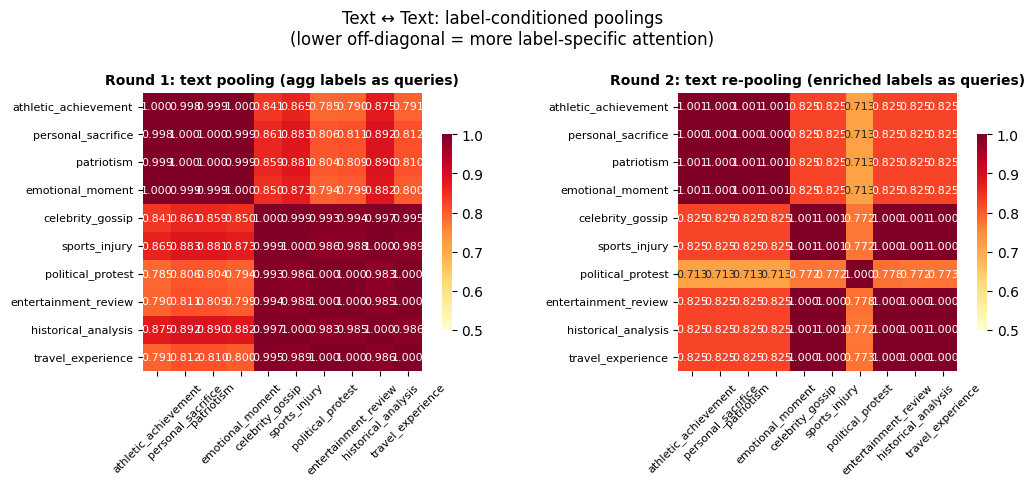

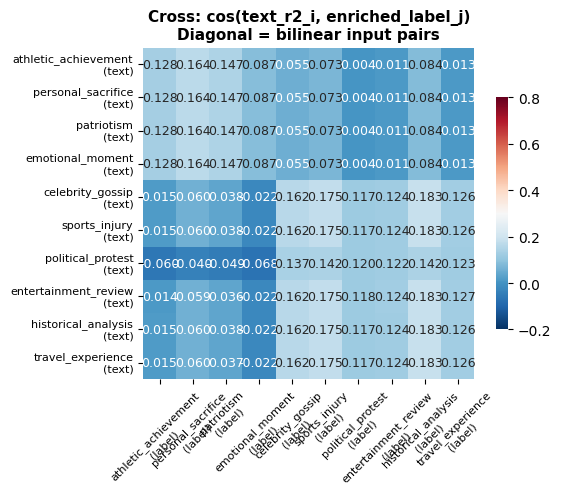


Diagonal — matched (text, label) pairs fed to bilinear:
Label                      cos(text_r2, enr_label)   Expected
──────────────────────────────────────────────────────────────
athletic_achievement                        0.1284       TRUE
personal_sacrifice                          0.1644       TRUE
patriotism                                  0.1471       TRUE
emotional_moment                            0.0872       TRUE
celebrity_gossip                            0.1617      FALSE
sports_injury                               0.1752      FALSE
political_protest                           0.1202      FALSE
entertainment_review                        0.1243      FALSE
historical_analysis                         0.1827      FALSE
travel_experience                           0.1263      FALSE


In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 1. LABEL ↔ LABEL at each stage
# ──────────────────────────────────────────────────────────────────────────────
sim_ll_raw = cos_sim(stages["raw_label_embs"], stages["raw_label_embs"])
sim_ll_agg = cos_sim(stages["agg_label_embs"], stages["agg_label_embs"])
sim_ll_enr = cos_sim(stages["enriched_label_embs"], stages["enriched_label_embs"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, sim, title in zip(axes,
    [sim_ll_raw, sim_ll_agg, sim_ll_enr],
    ["1. Raw [LAB]", "2. Aggregated", "3. Enriched"]):
    sns.heatmap(
        sim, ax=ax, vmin=-1, vmax=1, cmap="RdBu_r",
        xticklabels=labels, yticklabels=labels,
        annot=True, fmt=".2f", annot_kws={"size": 8},
        square=True, cbar_kws={"shrink": 0.7},
    )
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.suptitle("Label ↔ Label cosine similarity", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 2. TEXT ↔ TEXT at Round 1 and Round 2
# ──────────────────────────────────────────────────────────────────────────────
sim_tt_r1 = cos_sim(stages["text_r1"], stages["text_r1"])
sim_tt_r2 = cos_sim(stages["text_r2"], stages["text_r2"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, sim, title in zip(axes, [sim_tt_r1, sim_tt_r2],
    ["Round 1: text pooling (agg labels as queries)",
     "Round 2: text re-pooling (enriched labels as queries)"]):
    sns.heatmap(
        sim, ax=ax, vmin=0.5, vmax=1.0, cmap="YlOrRd",
        xticklabels=labels, yticklabels=labels,
        annot=True, fmt=".3f", annot_kws={"size": 8},
        square=True, cbar_kws={"shrink": 0.7},
    )
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.suptitle("Text ↔ Text: label-conditioned poolings\n(lower off-diagonal = more label-specific attention)", 
             fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# 3. CROSS: enriched_label_i × text_r2_j (full matrix)
#    Diagonal = the (text, label) pairs that go into bilinear scoring
# ──────────────────────────────────────────────────────────────────────────────
sim_cross = cos_sim(stages["text_r2"], stages["enriched_label_embs"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    sim_cross, ax=ax, vmin=-0.2, vmax=0.8, cmap="RdBu_r",
    xticklabels=[f"{l}\n(label)" for l in labels],
    yticklabels=[f"{l}\n(text)" for l in labels],
    annot=True, fmt=".3f", annot_kws={"size": 9},
    square=True, cbar_kws={"shrink": 0.7},
)
ax.set_title("Cross: cos(text_r2_i, enriched_label_j)\nDiagonal = bilinear input pairs", 
             fontsize=11, fontweight="bold")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)
plt.tight_layout()
plt.show()

# Print diagonal
print("\nDiagonal — matched (text, label) pairs fed to bilinear:")
print(f"{'Label':<25} {'cos(text_r2, enr_label)':>24} {'Expected':>10}")
print("─" * 62)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    print(f"{lbl:<25} {sim_cross[i, i]:>24.4f} {'TRUE' if exp else 'FALSE':>10}")

## Final Bilinear Scores

The scoring head takes `(text_r2, enriched_label)` pairs and produces logits via a learned bilinear form.


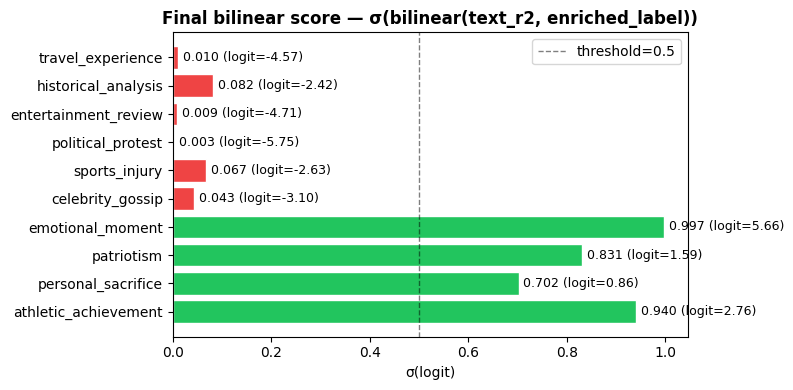


════════════════════════════════════════════════════════════════════════════════
FULL PROGRESSION: label↔text cosine at each stage → final bilinear decision
════════════════════════════════════════════════════════════════════════════════
Label                    Raw↔CLS   R1↔text   R2↔text   Logit      σ  Exp
────────────────────────────────────────────────────────────────────────────────
athletic_achievement       0.169     0.693     0.128    2.76  0.940   T ✓
personal_sacrifice         0.322     0.790     0.164    0.86  0.702   T ✓
patriotism                 0.221     0.731     0.147    1.59  0.831   T ✓
emotional_moment          -0.010     0.458     0.087    5.66  0.997   T ✓
celebrity_gossip           0.046     0.643     0.162   -3.10  0.043   F ✓
sports_injury              0.100     0.651     0.175   -2.63  0.067   F ✓
political_protest         -0.042     0.535     0.120   -5.75  0.003   F ✓
entertainment_review      -0.046     0.549     0.124   -4.71  0.009   F ✓
historical_anal

In [8]:
# Final bilinear scores
final_scores = stages["scores"].cpu().numpy()
final_logits = stages["logits"].cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#22c55e" if e else "#ef4444" for e in expected]
ax.barh(labels, final_scores, color=colors, edgecolor="white")
ax.set_xlabel("σ(logit)")
ax.set_title("Final bilinear score — σ(bilinear(text_r2, enriched_label))", fontweight="bold")
ax.axvline(0.5, color="black", ls="--", lw=1, alpha=0.5, label="threshold=0.5")
ax.legend()
for i, (v, l) in enumerate(zip(final_scores, final_logits)):
    ax.text(v + 0.01, i, f"{v:.3f} (logit={l:.2f})", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Full progression table
print("\n" + "═" * 80)
print("FULL PROGRESSION: label↔text cosine at each stage → final bilinear decision")
print("═" * 80)
print(f"{'Label':<22} {'Raw↔CLS':>9} {'R1↔text':>9} {'R2↔text':>9} {'Logit':>7} {'σ':>6} {'Exp':>4}")
print("─" * 80)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    mark = "✓" if (final_scores[i] > 0.5) == exp else "✗"
    print(f"{lbl:<22} {sim_raw[i]:>9.3f} {sim_r1[i]:>9.3f} {sim_r2[i]:>9.3f} "
          f"{final_logits[i]:>7.2f} {final_scores[i]:>6.3f} {'T' if exp else 'F':>3} {mark}")
print("─" * 80)
print("Raw↔CLS  = cos(raw_label, CLS)              — encoder alignment")
print("R1↔text  = cos(agg_label, text_pool_r1)     — after first cross-attention")
print("R2↔text  = cos(enriched_label, text_pool_r2) — after cooperative enrichment + re-pooling")
print("σ        = sigmoid(bilinear(text_r2, enriched_label))")

## Trajectory: Label↔Text Cosine Through the Pipeline

Each line traces one label's cosine similarity with its **stage-matched** text representation.
True labels (green) should separate from false labels (red) as we progress through the stages.


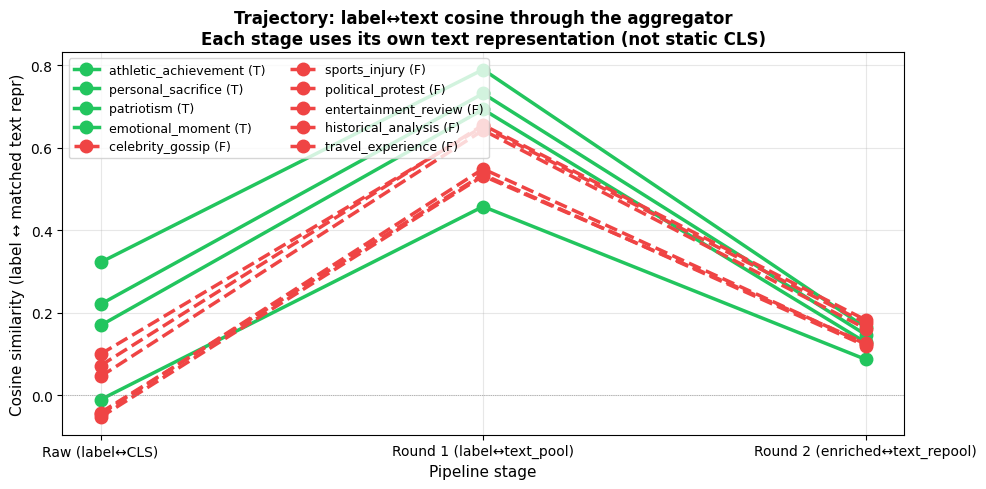


Label                    Raw↔CLS   R1↔text   R2↔text  Δ(R2-Raw)
───────────────────────────────────────────────────────────────
athletic_achievement       0.169     0.693     0.128     -0.041
personal_sacrifice         0.322     0.790     0.164     -0.158
patriotism                 0.221     0.731     0.147     -0.074
emotional_moment          -0.010     0.458     0.087     +0.098
celebrity_gossip           0.046     0.643     0.162     +0.116
sports_injury              0.100     0.651     0.175     +0.075
political_protest         -0.042     0.535     0.120     +0.162
entertainment_review      -0.046     0.549     0.124     +0.170
historical_analysis        0.072     0.655     0.183     +0.111
travel_experience         -0.053     0.532     0.126     +0.179


In [9]:
# Trajectory: label↔text cosine at each stage
stage_names = ["Raw (label↔CLS)", "Round 1 (label↔text_pool)", "Round 2 (enriched↔text_repool)"]

trajectory = np.column_stack([sim_raw, sim_r1, sim_r2])

fig, ax = plt.subplots(figsize=(10, 5))

for i, (lbl, exp) in enumerate(zip(labels, expected)):
    color = "#22c55e" if exp else "#ef4444"
    ls = "-" if exp else "--"
    ax.plot(stage_names, trajectory[i], marker="o", color=color, ls=ls,
            lw=2.5, markersize=9, label=f"{lbl} ({'T' if exp else 'F'})")

ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.set_ylabel("Cosine similarity (label ↔ matched text repr)", fontsize=11)
ax.set_xlabel("Pipeline stage", fontsize=11)
ax.set_title("Trajectory: label↔text cosine through the aggregator\n"
             "Each stage uses its own text representation (not static CLS)",
             fontweight="bold", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Delta table
print(f"\n{'Label':<22} {'Raw↔CLS':>9} {'R1↔text':>9} {'R2↔text':>9} {'Δ(R2-Raw)':>10}")
print("─" * 63)
for i, (lbl, exp) in enumerate(zip(labels, expected)):
    delta = trajectory[i, 2] - trajectory[i, 0]
    print(f"{lbl:<22} {trajectory[i,0]:>9.3f} {trajectory[i,1]:>9.3f} "
          f"{trajectory[i,2]:>9.3f} {delta:>+10.3f}")